#### 경로 설정
---

In [81]:
from pathlib import Path
import pandas as pd
import numpy as np

# 현재 노트북 위치: Donghaeng-LOTTO/analysis 라고 가정
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "kbo_pipeline" / "data" / "processed"

print(PROJECT_ROOT)
print(PROCESSED_DIR)
print(PROCESSED_DIR.exists())

d:\flatbass\Donghaeng-LOTTO
d:\flatbass\Donghaeng-LOTTO\kbo_pipeline\data\processed
True


### 데이터 프레임 만들기
---

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "kbo_pipeline" / "data" / "processed"

csv_files = sorted(PROCESSED_DIR.glob("*.csv"))

tables = {}

for path in csv_files:
    name = path.stem
    tables[name] = pd.read_csv(path, low_memory=False)
    print(f"{name:35s} rows={len(tables[name]):>8,} cols={len(tables[name].columns):>4}")

batter_game_boxscores               rows=  22,157 cols=  43
batter_pre_game_stats               rows=  22,157 cols=  22
dataset_quality_report              rows=     940 cols=  21
games                               rows=   1,777 cols=  18
games_detail                        rows=     874 cols=  17
model_master_pa                     rows=  67,840 cols= 207
model_master_pa_eligible            rows=   5,970 cols= 207
naver_players_seen                  rows=   1,001 cols=  18
pitcher_game_boxscores              rows=   8,337 cols=  26
pitcher_pre_game_stats              rows=   8,337 cols=  22
plate_appearances                   rows=  67,840 cols=  56
player_id_map                       rows=     846 cols=  17
player_id_map_unmatched             rows=      19 cols=  17
relay_events                        rows= 472,399 cols=  44
score_validation                    rows=     862 cols=   8
scoreboard_inning_scores            rows=     874 cols=  39


In [ ]:
model_master_pa_eligible = tables["model_master_pa_eligible"]
model_master_pa_eligible

,game_id,relay_no,inning,home_or_away,start_seqno,result_seqno,end_seqno,batter_pcode,pitcher_pcode,batter_name,...,same_hand_matchup,batter_platoon_advantage,state_is_ok,score_is_valid,core_fields_notna,outs_before_valid,inning_valid,model_eligible_base,model_eligible_with_player_stats,model_exclusion_reasons
0,20080601HTOB0,1,1,0,1,6,6,74163,75230,이용규,...,False,True,True,True,True,True,True,True,True,NaN
1,20080601HTOB0,2,1,0,7,9,9,93607,75230,이종범,...,True,False,True,True,True,True,True,True,True,NaN
2,20080601HTOB0,3,1,0,10,15,15,96610,75230,장성호,...,False,True,True,True,True,True,True,True,True,NaN
3,20080601HTOB0,4,1,0,16,18,18,92304,75230,이재주,...,True,False,True,True,True,True,True,True,True,NaN
4,20080601HTOB0,5,1,0,19,26,26,70117,75230,최경환,...,False,True,True,True,True,True,True,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5965,20080629SSOB0,77,9,0,429,433,433,93410,77251,양준혁,...,False,True,True,True,True,True,True,True,True,NaN
5966,20080629SSOB0,78,9,0,434,441,441,74465,71260,박석민,...,True,False,True,True,True,True,True,True,True,NaN
5967,20080629SSOB0,80,9,1,443,450,450,70240,74454,정원석,...,True,False,True,True,True,True,True,True,True,NaN
5968,20080629SSOB0,82,9,1,452,459,459,72220,75421,유재웅,...,False,True,True,True,True,True,True,True,True,NaN


### EDA 시작용 기본 점검
---

In [7]:
def table_summary(df, name):
    return {
        "table": name,
        "rows": len(df),
        "cols": len(df.columns),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "duplicated_rows": df.duplicated().sum(),
    }

summary = pd.DataFrame([
    table_summary(df, name)
    for name, df in tables.items()
]).sort_values("rows", ascending=False)

summary

,table,rows,cols,memory_mb,duplicated_rows
13,relay_events,472399,44,438.28,0
5,model_master_pa,67840,207,266.07,0
10,plate_appearances,67840,56,117.75,0
0,batter_game_boxscores,22157,43,24.00,0
1,batter_pre_game_stats,22157,22,8.00,0
9,pitcher_pre_game_stats,8337,22,3.07,0
8,pitcher_game_boxscores,8337,26,4.38,0
6,model_master_pa_eligible,5970,207,22.56,0
3,games,1777,18,1.21,0
7,naver_players_seen,1001,18,0.63,0


### 컬럼 확인용
---

In [8]:
def show_columns(df, keyword=None):
    cols = list(df.columns)
    
    if keyword:
        cols = [c for c in cols if keyword.lower() in c.lower()]
    
    for c in cols:
        print(c)
        
show_columns(master_pa_eligible)

game_id
relay_no
inning
home_or_away
start_seqno
result_seqno
end_seqno
batter_pcode
pitcher_pcode
batter_name
batter_order
batter_pos_name_x
pitch_count
result_event_type
result_text
runner_before_result_text
runner_after_result_text
change_text
has_runner_movement_before_result
has_runner_movement_after_result
has_player_change
is_scoring_pa_result
pa_result_type
outs_before
base1_before
base2_before
base3_before
away_score_before
home_score_before
away_score_after
home_score_after
state_source
state_parse_status
parse_warning
base_state_before
pitcher_pcode_norm
pitcher_name
batter_pcode_norm
away_team_code
home_team_code
away_score
home_score
winner_team_code
is_top
batting_team_code
fielding_team_code
is_lotte_batting
is_lotte_fielding
lotte_score_before
opponent_score_before
score_diff_lotte_before
scoring_position_before
late_clutch
home_win
away_win
final_win_label_lotte
game_date
game_time
stadium
away_team_name
away_team_full_name
home_team_name
home_team_full_name
away_start

In [9]:
def missing_summary(df):
    result = (
        df.isna()
        .sum()
        .reset_index()
        .rename(columns={"index": "column", 0: "missing_count"})
    )
    result["missing_ratio"] = result["missing_count"] / len(df)
    return result.sort_values("missing_ratio", ascending=False)

missing_summary(master_pa_eligible).head(30)

,column,missing_count,missing_ratio
33,parse_warning,5970,1.000000
206,model_exclusion_reasons,5970,1.000000
144,pitcher_pos_name,5799,0.971357
15,runner_before_result_text,5763,0.965327
17,change_text,5291,0.886265
16,runner_after_result_text,5051,0.846064
49,opponent_score_before,4516,0.756449
48,lotte_score_before,4516,0.756449
93,lotte_win_label,4516,0.756449
50,score_diff_lotte_before,4516,0.756449


### 모델 마스터 테이블(model_master_pa)
---

In [10]:
master = tables["model_master_pa"]
eligible = tables["model_master_pa_eligible"]

master.shape, eligible.shape

((67840, 207), (5970, 207))

#### 승패 라벨 분포 확인
---

In [14]:
eligible["batting_team_win_label"].value_counts(dropna=False)

batting_team_win_label
1.0    3036
0.0    2934
Name: count, dtype: int64

In [15]:
eligible["home_win_label"].value_counts(dropna=False)

home_win_label
1.0    3460
0.0    2510
Name: count, dtype: int64

In [16]:
eligible["lotte_win_label"].value_counts(dropna=False)

lotte_win_label
NaN    4516
0.0     729
1.0     725
Name: count, dtype: int64

- 비율로 보기

In [17]:
eligible["batting_team_win_label"].value_counts(normalize=True, dropna=False)

batting_team_win_label
1.0    0.508543
0.0    0.491457
Name: proportion, dtype: float64

#### 이닝별 공격팀 승률 보기
---

In [18]:
inning_win = (
    eligible
    .groupby("inning")["batting_team_win_label"]
    .mean()
    .reset_index()
)

inning_win

,inning,batting_team_win_label
0,1,0.525148
1,2,0.515337
2,3,0.515837
3,4,0.513473
4,5,0.525849
5,6,0.539589
6,7,0.515576
7,8,0.518195
8,9,0.382294
9,10,0.405405


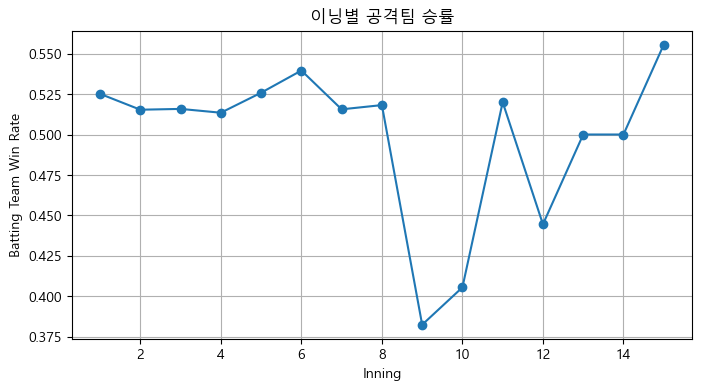

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# Windows 기본 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 기본 그래프 크기
plt.rcParams["figure.figsize"] = (10, 5)

# 해상도
plt.rcParams["figure.dpi"] = 100

plt.figure(figsize=(8, 4))
plt.plot(inning_win["inning"], inning_win["batting_team_win_label"], marker="o")
plt.xlabel("Inning")
plt.ylabel("Batting Team Win Rate")
plt.title("이닝별 공격팀 승률")
plt.grid(True)
plt.show()

#### 점수차별 승률 보기
---

In [20]:
score_diff_win = (
    eligible
    .groupby("batting_score_diff_before")["batting_team_win_label"]
    .agg(["count", "mean"])
    .reset_index()
    .sort_values("batting_score_diff_before")
)

score_diff_win

# 표본이 너무 적은 점수차는 제외
score_diff_win_filtered = score_diff_win[score_diff_win["count"] >= 20]
score_diff_win_filtered

,batting_score_diff_before,count,mean
6,-11,35,0.000000
7,-10,49,0.000000
8,-9,32,0.000000
9,-8,66,0.000000
10,-7,85,0.000000
11,-6,117,0.000000
12,-5,242,0.000000
13,-4,267,0.000000
14,-3,272,0.084559
15,-2,356,0.224719


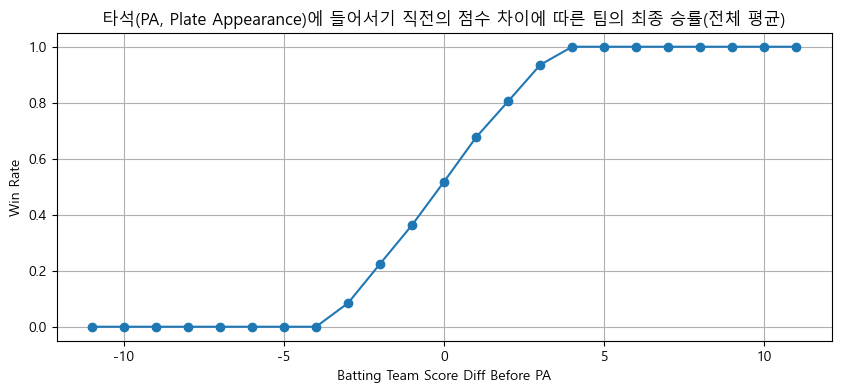

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(
    score_diff_win_filtered["batting_score_diff_before"],
    score_diff_win_filtered["mean"],
    marker="o"
)
plt.xlabel("Batting Team Score Diff Before PA")
plt.ylabel("Win Rate")
plt.title("타석(PA, Plate Appearance)에 들어서기 직전의 점수 차이에 따른 팀의 최종 승률(전체 평균)")
plt.grid(True)
plt.show()

- 현재 점수차가 최종 승패를 얼마나 강하게 설명하는가를 보여주는 그래프
- 그러나 현재 그래프에는 이닝 정보가 빠진 점수차만을 기준으로 본 평균 최종 승률이기 때문에 해석에 주의해야함.
- “점수차 → 승률” 관계가 확률의 0~1 제한과 스포츠 승패 구조 때문에 자연스럽게 S자 형태를 띤다.(어떤 스포츠든 현재 앞서고 있는 팀이 최종적으로 이길 확률은 높아지기 때문에)
    - 타석 직전 점수차가 커질수록 최종 승리확률은 올라가지만 확률은 0과 1사이에 갇혀있어서 양끝으로 갈수록 완만해진다.
        - 점수차가 -10점이면 거의 짐 → 승률 0 근처.
        - 점수차가 0점이면 반반 → 승률 0.5 근처.
        - 점수차가 +10점이면 거의 이김 → 승률 1 근처.

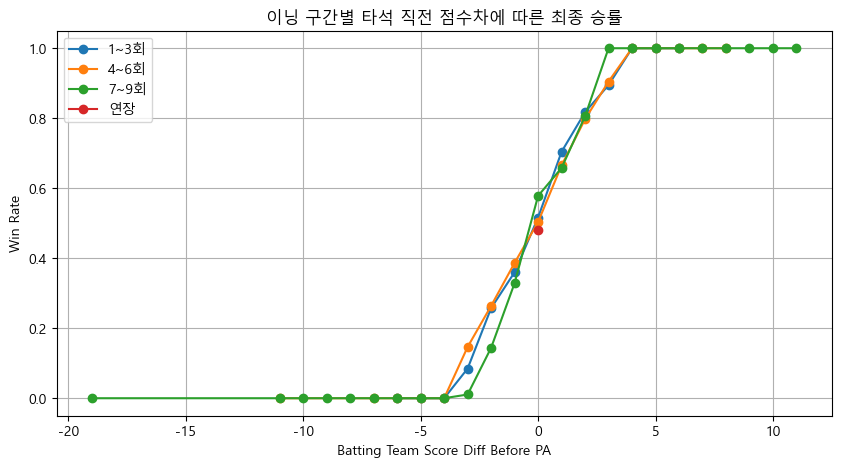

In [35]:
# 이닝 구간별로 나눠서 점수차별 승률 보기
import pandas as pd
from pathlib import Path

# 노트북 위치가 Donghaeng-LOTTO/analysis 라면
DATA_DIR = Path("../kbo_pipeline/data/processed")

df = pd.read_csv(DATA_DIR / "model_master_pa_eligible.csv")

df.shape, df.columns[:20]

# 필요한 컬럼만 확인
need_cols = [
    "inning",
    "batting_score_diff_before",
    "batting_team_win_label",
]

df[need_cols].isna().sum()

# 분석에 필요한 컬럼 결측 제거
df_plot = df.dropna(subset=need_cols).copy()

# 타입 정리
df_plot["inning"] = df_plot["inning"].astype(int)
df_plot["batting_score_diff_before"] = df_plot["batting_score_diff_before"].astype(int)
df_plot["batting_team_win_label"] = df_plot["batting_team_win_label"].astype(int)

# 이닝 구간별로 나누기
df_plot["inning_group"] = pd.cut(
    df_plot["inning"],
    bins=[0, 3, 6, 9, 99],
    labels=["1~3회", "4~6회", "7~9회", "연장"]
)

score_diff_by_inning = (
    df_plot
    .groupby(["inning_group", "batting_score_diff_before"], observed=True)["batting_team_win_label"]
    .agg(["mean", "count"])
    .reset_index()
)

# 표본 너무 적은 점수차 제거
score_diff_by_inning = score_diff_by_inning[
    score_diff_by_inning["count"] >= 10
]

score_diff_by_inning.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for group, g in score_diff_by_inning.groupby("inning_group", observed=True):
    plt.plot(
        g["batting_score_diff_before"],
        g["mean"],
        marker="o",
        label=group
    )

plt.xlabel("Batting Team Score Diff Before PA")
plt.ylabel("Win Rate")
plt.title("이닝 구간별 타석 직전 점수차에 따른 최종 승률")
plt.grid(True)
plt.legend()
plt.show()

- 연장전 살펴보기

In [37]:
extra = df_plot[df_plot["inning_group"] == "연장"].copy()

extra_check = (
    extra
    .groupby(["is_top_bool", "batting_score_diff_before"])["batting_team_win_label"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values(["batting_score_diff_before", "is_top_bool"])
)

extra_check

,is_top_bool,batting_score_diff_before,mean,count
0,False,-3,0.000000,3
1,False,0,1.000000,58
2,True,0,0.015385,65


- 0행 : 연장전 말(홈팀) 공격 상황에서 타석 직전 공격팀이 3점 뒤지고 있던 PA 3개, 공격팀은 한번도 이기지 못함
- 1행 : 연장전 말(홈팀) 공격 상황에서 타석 직전 공격/수비가 동점일 경우 PA 58개, 공격팀이 모두 이김

In [38]:
extra_game_check = (
    extra
    .groupby(["is_top_bool", "batting_score_diff_before"])
    .agg(
        pa_count=("batting_team_win_label", "size"),
        game_count=("game_id", "nunique"),
        win_rate=("batting_team_win_label", "mean")
    )
    .reset_index()
    .sort_values(["batting_score_diff_before", "is_top_bool"])
)

extra_game_check

,is_top_bool,batting_score_diff_before,pa_count,game_count,win_rate
0,False,-3,3,1,0.000000
1,False,0,58,5,1.000000
2,True,0,65,6,0.015385


#### 롯데
---

In [41]:
df["away_team_code"].unique(), df["home_team_code"].unique()

LOTTE = "LT"
lotte_df = df[
    (df["away_team_code"] == LOTTE) |
    (df["home_team_code"] == LOTTE)
].copy()

lotte_df.shape

(1454, 207)

In [43]:
lotte_df["lotte_score_diff_before"] = lotte_df.apply(
    lambda row: row["batting_score_diff_before"]
    if row["batting_team_code"] == LOTTE
    else -row["batting_score_diff_before"],
    axis=1
)

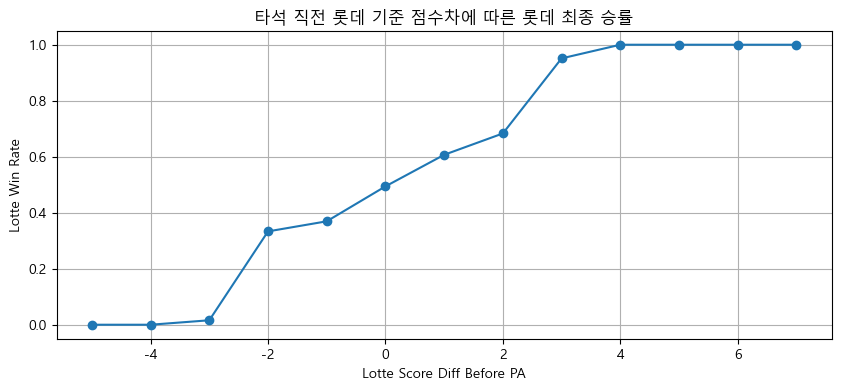

In [45]:
import matplotlib.pyplot as plt

lotte_score_diff_win = (
    lotte_df
    .dropna(subset=["lotte_score_diff_before", "lotte_win_label"])
    .groupby("lotte_score_diff_before")["lotte_win_label"]
    .agg(["mean", "count"])
    .reset_index()
)

# 표본 너무 적은 점수차 제거
lotte_score_diff_win_filtered = lotte_score_diff_win[
    lotte_score_diff_win["count"] >= 20
]

plt.figure(figsize=(10, 4))
plt.plot(
    lotte_score_diff_win_filtered["lotte_score_diff_before"],
    lotte_score_diff_win_filtered["mean"],
    marker="o"
)

plt.xlabel("Lotte Score Diff Before PA")
plt.ylabel("Lotte Win Rate")
plt.title("타석 직전 롯데 기준 점수차에 따른 롯데 최종 승률")
plt.grid(True)
plt.show()

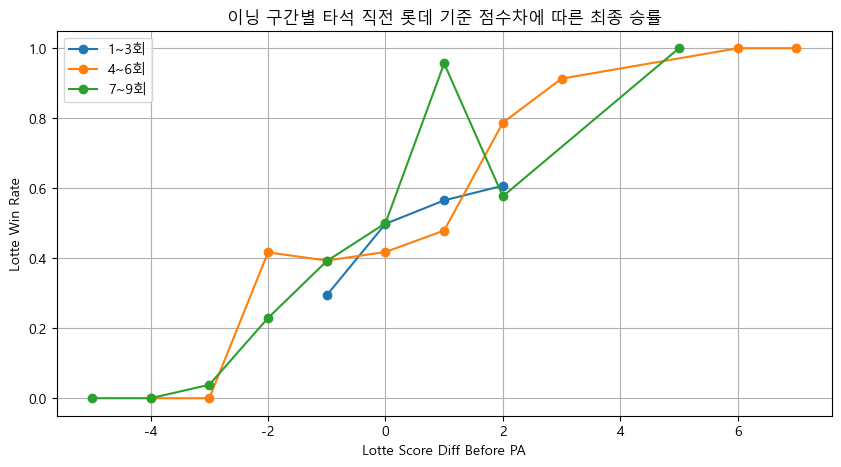

In [46]:
lotte_plot = lotte_df.dropna(
    subset=["inning", "lotte_score_diff_before", "lotte_win_label"]
).copy()

lotte_plot["inning"] = lotte_plot["inning"].astype(int)
lotte_plot["lotte_score_diff_before"] = lotte_plot["lotte_score_diff_before"].astype(int)
lotte_plot["lotte_win_label"] = lotte_plot["lotte_win_label"].astype(int)

lotte_plot["inning_group"] = pd.cut(
    lotte_plot["inning"],
    bins=[0, 3, 6, 9, 99],
    labels=["1~3회", "4~6회", "7~9회", "연장"]
)

lotte_by_inning = (
    lotte_plot
    .groupby(["inning_group", "lotte_score_diff_before"], observed=True)["lotte_win_label"]
    .agg(["mean", "count"])
    .reset_index()
)

lotte_by_inning = lotte_by_inning[
    lotte_by_inning["count"] >= 20
]

plt.figure(figsize=(10, 5))

for group, g in lotte_by_inning.groupby("inning_group", observed=True):
    plt.plot(
        g["lotte_score_diff_before"],
        g["mean"],
        marker="o",
        label=group
    )

plt.xlabel("Lotte Score Diff Before PA")
plt.ylabel("Lotte Win Rate")
plt.title("이닝 구간별 타석 직전 롯데 기준 점수차에 따른 최종 승률")
plt.grid(True)
plt.legend()
plt.show()

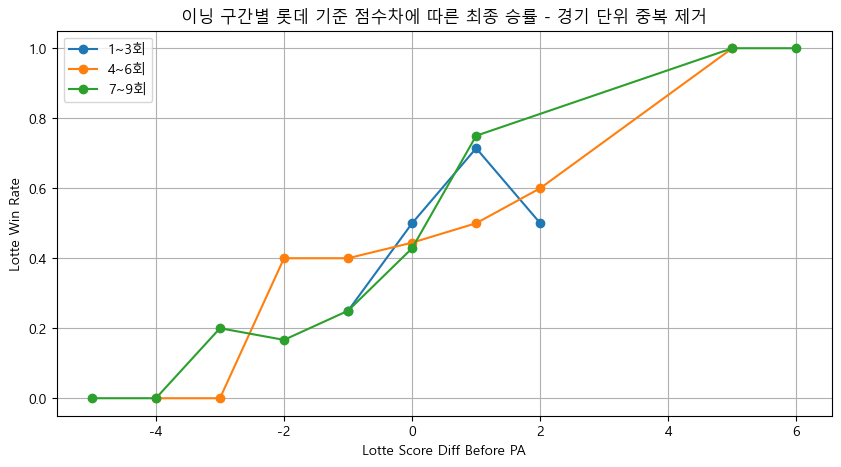

In [52]:
lotte_game_level = (
    lotte_plot
    .drop_duplicates(
        subset=["game_id", "inning_group", "lotte_score_diff_before"]
    )
    .groupby(["inning_group", "lotte_score_diff_before"], observed=True)
    .agg(
        win_rate=("lotte_win_label", "mean"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

lotte_game_level = lotte_game_level[
    lotte_game_level["game_count"] >= 3
]

plt.figure(figsize=(10, 5))

for group, g in lotte_game_level.groupby("inning_group", observed=True):
    plt.plot(
        g["lotte_score_diff_before"],
        g["win_rate"],
        marker="o",
        label=group
    )

plt.xlabel("Lotte Score Diff Before PA")
plt.ylabel("Lotte Win Rate")
plt.title("이닝 구간별 롯데 기준 점수차에 따른 최종 승률 - 경기 단위 중복 제거")
plt.grid(True)
plt.legend()
plt.show()

- 이닝 중반(4-6회) 롯데가 조금 앞서고 있어도 최종 승리를 안정적으로 가져가지는 못함.
    - 1~2점 리드 상황은 안전하지 않았다.
- 초반의 우세를 후반까지 가져가지 못하는 것으로 보인다.
- 현재 표본(2024년)에서 롯데는 소폭 리드 상황의 승리 전환율이 높지 않았고, 일정 점수차 이상으로 크게 앞선 경우에야 승률이 급격히 안정되는 패턴을 보였다(운빨대승)

In [53]:
lotte_lead_summary = (
    lotte_plot[lotte_plot["lotte_score_diff_before"] > 0]
    .drop_duplicates(
        subset=["game_id", "inning_group", "lotte_score_diff_before"]
    )
    .groupby(["inning_group", "lotte_score_diff_before"], observed=True)
    .agg(
        game_count=("game_id", "nunique"),
        win_rate=("lotte_win_label", "mean")
    )
    .reset_index()
)

lotte_lead_summary["loss_rate"] = 1 - lotte_lead_summary["win_rate"]

lotte_lead_summary.sort_values(
    ["inning_group", "lotte_score_diff_before"]
)

,inning_group,lotte_score_diff_before,game_count,win_rate,loss_rate
0,1~3회,1,7,0.714286,0.285714
1,1~3회,2,4,0.500000,0.500000
2,1~3회,4,1,1.000000,0.000000
3,1~3회,5,2,1.000000,0.000000
4,1~3회,7,1,1.000000,0.000000
5,4~6회,1,8,0.500000,0.500000
6,4~6회,2,5,0.600000,0.400000
7,4~6회,3,2,0.500000,0.500000
8,4~6회,4,2,1.000000,0.000000
9,4~6회,5,3,1.000000,0.000000


### 전체 KBO 기준, 롯데, 표본 내 최다 승팀 이닝별 승률

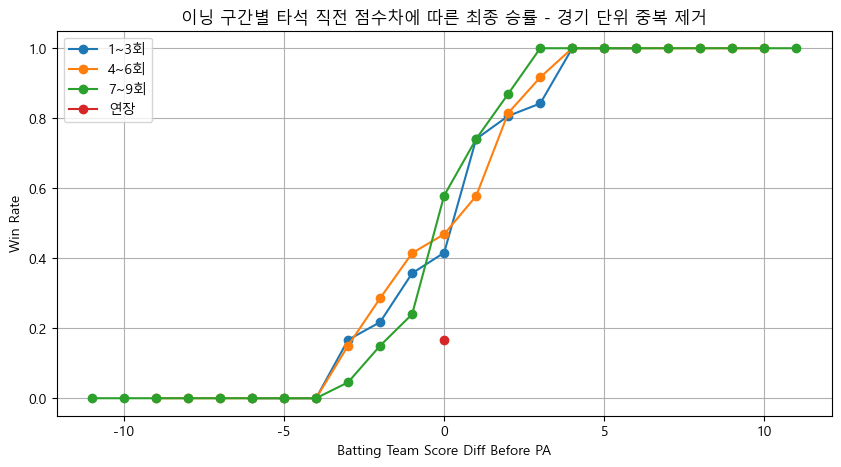

In [72]:
df_game_level = df_plot.drop_duplicates(
    subset=["game_id", "inning_group", "batting_score_diff_before"]
).copy()

score_diff_by_inning_game = (
    df_game_level
    .groupby(["inning_group", "batting_score_diff_before"], observed=True)
    .agg(
        win_rate=("batting_team_win_label", "mean"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

score_diff_by_inning_game = score_diff_by_inning_game[
    score_diff_by_inning_game["game_count"] >= 3
]

plt.figure(figsize=(10, 5))

for group, g in score_diff_by_inning_game.groupby("inning_group", observed=True):
    plt.plot(
        g["batting_score_diff_before"],
        g["win_rate"],
        marker="o",
        label=group
    )

plt.xlabel("Batting Team Score Diff Before PA")
plt.ylabel("Win Rate")
plt.title("이닝 구간별 타석 직전 점수차에 따른 최종 승률 - 경기 단위 중복 제거")
plt.grid(True)
plt.legend()
plt.show()

- team_score_diff_before = 해당 팀 점수 - 상대 팀 점수
- team_win_label = 해당 팀이 최종 승리했는지

SK 포함 PA 수: 1485
SK 포함 경기 수: 22


,inning_group,sk_score_diff_before,win_rate,game_count
2,1~3회,-2,0.500000,4
3,1~3회,-1,0.800000,5
4,1~3회,0,0.863636,22
5,1~3회,1,1.000000,6
6,1~3회,2,1.000000,3
7,1~3회,3,1.000000,4
8,1~3회,4,1.000000,5
17,4~6회,-1,0.777778,9
18,4~6회,0,0.888889,9
19,4~6회,1,1.000000,8


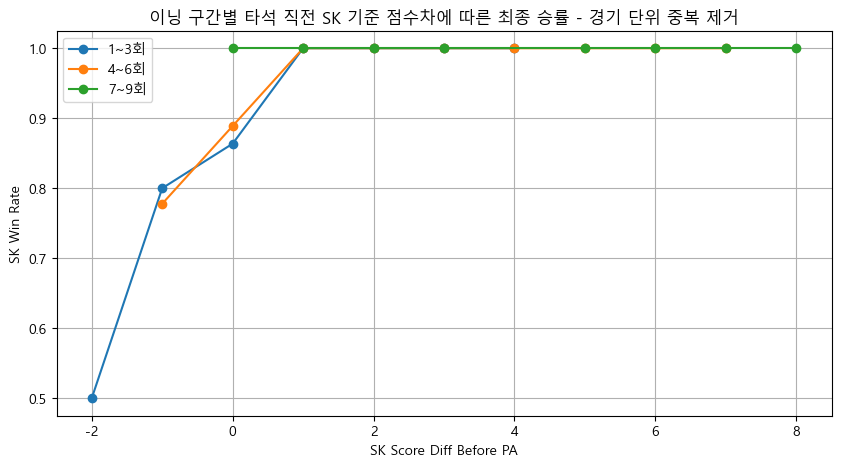

In [73]:
import numpy as np
import matplotlib.pyplot as plt

SK = "SK"

# SK가 포함된 경기만 필터링
sk_df = df_plot[
    (df_plot["away_team_code"] == SK) |
    (df_plot["home_team_code"] == SK)
].copy()

print("SK 포함 PA 수:", len(sk_df))
print("SK 포함 경기 수:", sk_df["game_id"].nunique())

# batting_team_code가 없으면 생성
if "batting_team_code" not in sk_df.columns:
    sk_df["batting_team_code"] = np.where(
        sk_df["is_top_bool"].astype(bool),
        sk_df["away_team_code"],
        sk_df["home_team_code"]
    )

# SK 기준 점수차 만들기
# SK가 공격 중이면 batting_score_diff_before 그대로
# 상대가 공격 중이면 부호 반대로
sk_df["sk_score_diff_before"] = np.where(
    sk_df["batting_team_code"] == SK,
    sk_df["batting_score_diff_before"],
    -sk_df["batting_score_diff_before"]
)

# SK 승리 라벨 만들기
# lotte_win_label처럼 sk_win_label이 없으니까 winner_team_code 기준으로 직접 생성
sk_df["sk_win_label"] = (sk_df["winner_team_code"] == SK).astype(int)

# 경기 단위 중복 제거
# 같은 경기에서 같은 이닝구간 + 같은 SK 기준 점수차는 1번만 반영
sk_game_level = sk_df.drop_duplicates(
    subset=["game_id", "inning_group", "sk_score_diff_before"]
).copy()

score_diff_by_inning_sk = (
    sk_game_level
    .groupby(["inning_group", "sk_score_diff_before"], observed=True)
    .agg(
        win_rate=("sk_win_label", "mean"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

# 표본 너무 적은 구간 제거
score_diff_by_inning_sk = score_diff_by_inning_sk[
    score_diff_by_inning_sk["game_count"] >= 3
]

display(
    score_diff_by_inning_sk.sort_values(
        ["inning_group", "sk_score_diff_before"]
    )
)

plt.figure(figsize=(10, 5))

for group, g in score_diff_by_inning_sk.groupby("inning_group", observed=True):
    g = g.sort_values("sk_score_diff_before")
    plt.plot(
        g["sk_score_diff_before"],
        g["win_rate"],
        marker="o",
        label=group
    )

plt.xlabel("SK Score Diff Before PA")
plt.ylabel("SK Win Rate")
plt.title("이닝 구간별 타석 직전 SK 기준 점수차에 따른 최종 승률 - 경기 단위 중복 제거")
plt.grid(True)
plt.legend()
plt.show()

LT 포함 PA 수: 1454
LT 포함 경기 수: 22


,inning_group,lt_score_diff_before,win_rate,game_count
3,1~3회,-1,0.250000,8
4,1~3회,0,0.500000,22
5,1~3회,1,0.714286,7
6,1~3회,2,0.500000,4
12,4~6회,-4,0.000000,4
13,4~6회,-3,0.000000,4
14,4~6회,-2,0.400000,5
15,4~6회,-1,0.400000,10
16,4~6회,0,0.444444,9
17,4~6회,1,0.500000,8


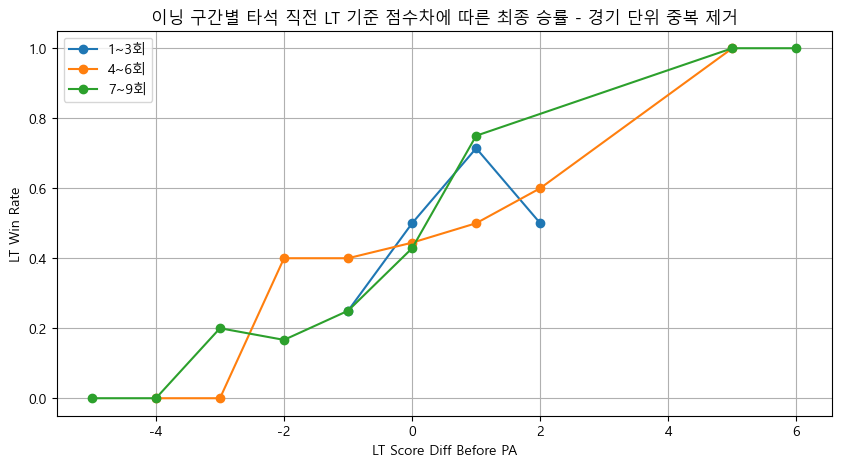

In [79]:
import numpy as np
import matplotlib.pyplot as plt

LT = "LT"

# LT가 포함된 경기만 필터링
lt_df = df_plot[
    (df_plot["away_team_code"] == LT) |
    (df_plot["home_team_code"] == LT)
].copy()

print("LT 포함 PA 수:", len(lt_df))
print("LT 포함 경기 수:", lt_df["game_id"].nunique())

# batting_team_code가 없으면 생성
if "batting_team_code" not in lt_df.columns:
    lt_df["batting_team_code"] = np.where(
        lt_df["is_top_bool"].astype(bool),
        lt_df["away_team_code"],
        lt_df["home_team_code"]
    )

# LT 기준 점수차 만들기
# LT가 공격 중이면 batting_score_diff_before 그대로
# 상대가 공격 중이면 부호 반대로
lt_df["lt_score_diff_before"] = np.where(
    lt_df["batting_team_code"] == LT,
    lt_df["batting_score_diff_before"],
    -lt_df["batting_score_diff_before"]
)

# LT 승리 라벨 만들기
# lotte_win_label처럼 sk_win_label이 없으니까 winner_team_code 기준으로 직접 생성
lt_df["lt_win_label"] = (lt_df["winner_team_code"] == LT).astype(int)

# 경기 단위 중복 제거
# 같은 경기에서 같은 이닝구간 + 같은 LT 기준 점수차는 1번만 반영
lt_game_level = lt_df.drop_duplicates(
    subset=["game_id", "inning_group", "lt_score_diff_before"]
).copy()

score_diff_by_inning_lt = (
    lt_game_level
    .groupby(["inning_group", "lt_score_diff_before"], observed=True)
    .agg(
        win_rate=("lt_win_label", "mean"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

# 표본 너무 적은 구간 제거
score_diff_by_inning_lt = score_diff_by_inning_lt[
    score_diff_by_inning_lt["game_count"] >= 3
]

display(
    score_diff_by_inning_lt.sort_values(
        ["inning_group", "lt_score_diff_before"]
    )
)

plt.figure(figsize=(10, 5))

for group, g in score_diff_by_inning_lt.groupby("inning_group", observed=True):
    g = g.sort_values("lt_score_diff_before")
    plt.plot(
        g["lt_score_diff_before"],
        g["win_rate"],
        marker="o",
        label=group
    )

plt.xlabel("LT Score Diff Before PA")
plt.ylabel("LT Win Rate")
plt.title("이닝 구간별 타석 직전 LT 기준 점수차에 따른 최종 승률 - 경기 단위 중복 제거")
plt.grid(True)
plt.legend()
plt.show()

In [83]:
import numpy as np

def make_team_view(df_plot, team_code):
    team_df = df_plot[
        (df_plot["away_team_code"] == team_code) |
        (df_plot["home_team_code"] == team_code)
    ].copy()

    if "batting_team_code" not in team_df.columns:
        team_df["batting_team_code"] = np.where(
            team_df["is_top_bool"].astype(bool),
            team_df["away_team_code"],
            team_df["home_team_code"]
        )

    team_df[f"{team_code}_score_diff_before"] = np.where(
        team_df["batting_team_code"] == team_code,
        team_df["batting_score_diff_before"],
        -team_df["batting_score_diff_before"]
    )

    team_df[f"{team_code}_win_label"] = (
        team_df["winner_team_code"] == team_code
    ).astype(int)

    # 같은 경기 + 같은 이닝구간 + 같은 점수차는 1번만 반영
    game_level = team_df.drop_duplicates(
        subset=["game_id", "inning_group", f"{team_code}_score_diff_before"]
    ).copy()

    return game_level


def summarize_team_style(df_plot, team_code):
    game_level = make_team_view(df_plot, team_code)

    diff_col = f"{team_code}_score_diff_before"
    win_col = f"{team_code}_win_label"

    def rate(condition):
        sub = game_level[condition]
        if len(sub) == 0:
            return None, 0
        return sub[win_col].mean(), sub["game_id"].nunique()

    mid_small, mid_n = rate(
        (game_level["inning_group"] == "4~6회") &
        (game_level[diff_col].between(1, 3))
    )

    late_small, late_n = rate(
        (game_level["inning_group"] == "7~9회") &
        (game_level[diff_col].between(1, 2))
    )

    late_tie_or_lead, late_tie_n = rate(
        (game_level["inning_group"] == "7~9회") &
        (game_level[diff_col] >= 0)
    )

    comeback_mid, comeback_mid_n = rate(
        (game_level["inning_group"] == "4~6회") &
        (game_level[diff_col] < 0)
    )

    comeback_late, comeback_late_n = rate(
        (game_level["inning_group"] == "7~9회") &
        (game_level[diff_col] < 0)
    )

    big_lead, big_n = rate(
        game_level[diff_col] >= 4
    )

    total_games = game_level["game_id"].nunique()
    wins = game_level.drop_duplicates("game_id")[win_col].sum()

    return pd.DataFrame([{
        "team": team_code,
        "games": total_games,
        "wins": int(wins),
        "losses": int(total_games - wins),
        "overall_win_rate": wins / total_games if total_games else None,

        "mid_4_6_small_lead_win_rate": mid_small,
        "mid_4_6_small_lead_games": mid_n,

        "late_7_9_small_lead_win_rate": late_small,
        "late_7_9_small_lead_games": late_n,

        "late_7_9_tie_or_lead_win_rate": late_tie_or_lead,
        "late_7_9_tie_or_lead_games": late_tie_n,

        "mid_4_6_trailing_win_rate": comeback_mid,
        "mid_4_6_trailing_games": comeback_mid_n,

        "late_7_9_trailing_win_rate": comeback_late,
        "late_7_9_trailing_games": comeback_late_n,

        "big_lead_4plus_win_rate": big_lead,
        "big_lead_4plus_games": big_n,
    }])


style_compare = pd.concat([
    summarize_team_style(df_plot, "SK"),
    summarize_team_style(df_plot, "LT"),
], ignore_index=True)

display(style_compare)

,team,games,wins,losses,overall_win_rate,mid_4_6_small_lead_win_rate,mid_4_6_small_lead_games,late_7_9_small_lead_win_rate,late_7_9_small_lead_games,late_7_9_tie_or_lead_win_rate,late_7_9_tie_or_lead_games,mid_4_6_trailing_win_rate,mid_4_6_trailing_games,late_7_9_trailing_win_rate,late_7_9_trailing_games,big_lead_4plus_win_rate,big_lead_4plus_games
0,SK,22,19,3,0.863636,1.000000,10,1.000000,7,1.000000,19,0.60,10,0.142857,4,1.0,10
1,LT,22,11,11,0.500000,0.533333,11,0.666667,4,0.777778,15,0.24,13,0.133333,14,1.0,5


### 아웃카운트별 주자상태에 따른 승률

,outs_before,base_state_before,base_state_label,win_rate,pa_count,game_count
0,0,000,주자 없음,0.494788,1631,89
1,0,001,3루,0.837838,37,27
2,0,010,2루,0.561905,105,62
3,0,011,"2,3루",0.550000,20,17
4,0,100,1루,0.507246,345,88
5,0,101,"1,3루",0.875000,8,8
6,0,110,"1,2루",0.545455,11,10
7,0,111,만루,0.000000,1,1
8,1,000,주자 없음,0.483926,1182,89
9,1,001,3루,0.666667,111,63


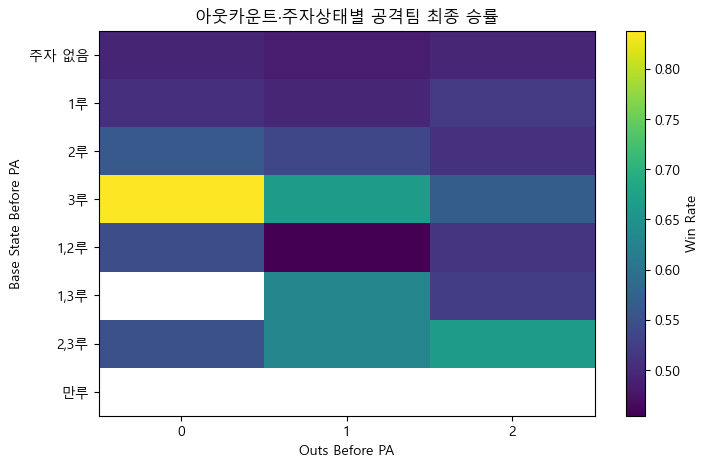

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../kbo_pipeline/data/processed")
df = pd.read_csv(DATA_DIR / "model_master_pa_eligible.csv")

# 필요한 컬럼
need_cols = [
    "game_id",
    "inning",
    "outs_before",
    "base1_before",
    "base2_before",
    "base3_before",
    "batting_team_win_label",
]

df_bo = df.dropna(subset=need_cols).copy()

df_bo["inning"] = df_bo["inning"].astype(int)
df_bo["outs_before"] = df_bo["outs_before"].astype(int)
df_bo["base1_before"] = df_bo["base1_before"].astype(int)
df_bo["base2_before"] = df_bo["base2_before"].astype(int)
df_bo["base3_before"] = df_bo["base3_before"].astype(int)
df_bo["batting_team_win_label"] = df_bo["batting_team_win_label"].astype(int)

# 주자 상태 문자열 만들기
df_bo["base_state_before"] = (
    df_bo["base1_before"].astype(str)
    + df_bo["base2_before"].astype(str)
    + df_bo["base3_before"].astype(str)
)

# 보기 좋은 라벨
base_state_label_map = {
    "000": "주자 없음",
    "100": "1루",
    "010": "2루",
    "001": "3루",
    "110": "1,2루",
    "101": "1,3루",
    "011": "2,3루",
    "111": "만루",
}

df_bo["base_state_label"] = df_bo["base_state_before"].map(base_state_label_map)

base_out_summary = (
    df_bo
    .groupby(["outs_before", "base_state_before", "base_state_label"], observed=True)
    .agg(
        win_rate=("batting_team_win_label", "mean"),
        pa_count=("batting_team_win_label", "size"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
    .sort_values(["outs_before", "base_state_before"])
)

display(base_out_summary)

# 표본 너무 적은 상태 제거
heat_df = base_out_summary[base_out_summary["pa_count"] >= 10].copy()

pivot = heat_df.pivot(
    index="base_state_label",
    columns="outs_before",
    values="win_rate"
)

# 주자 상태 순서 고정
base_order = [
    "주자 없음",
    "1루",
    "2루",
    "3루",
    "1,2루",
    "1,3루",
    "2,3루",
    "만루",
]

pivot = pivot.reindex(base_order)

plt.figure(figsize=(8, 5))
plt.imshow(pivot, aspect="auto")

plt.colorbar(label="Win Rate")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Outs Before PA")
plt.ylabel("Base State Before PA")
plt.title("아웃카운트·주자상태별 공격팀 최종 승률")
plt.show()

In [88]:
def score_bucket(x):
    if x <= -4:
        return "큰 열세(-4 이하)"
    elif x <= -1:
        return "열세(-1~-3)"
    elif x == 0:
        return "동점"
    elif x <= 3:
        return "리드(+1~+3)"
    else:
        return "큰 리드(+4 이상)"

df_bo["score_bucket"] = df_bo["batting_score_diff_before"].apply(score_bucket)

base_out_score_summary = (
    df_bo
    .groupby(
        ["score_bucket", "outs_before", "base_state_label"],
        observed=True
    )
    .agg(
        win_rate=("batting_team_win_label", "mean"),
        pa_count=("batting_team_win_label", "size"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

display(
    base_out_score_summary.sort_values(
        ["score_bucket", "outs_before", "base_state_label"]
    )
)

,score_bucket,outs_before,base_state_label,win_rate,pa_count,game_count
0,동점,0,"1,2루",0.500000,2,2
1,동점,0,1루,0.529412,102,54
2,동점,0,"2,3루",1.000000,4,4
3,동점,0,2루,0.615385,26,24
4,동점,0,3루,1.000000,5,5
...,...,...,...,...,...,...
103,큰 열세(-4 이하),2,1루,0.000000,47,33
104,큰 열세(-4 이하),2,"2,3루",0.000000,2,2
105,큰 열세(-4 이하),2,2루,0.000000,35,23
106,큰 열세(-4 이하),2,3루,0.000000,22,20


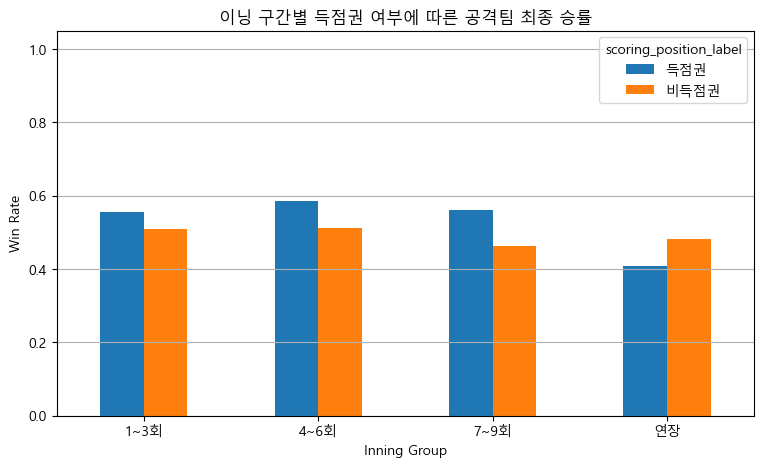

In [90]:
df_bo["inning_group"] = pd.cut(
    df_bo["inning"],
    bins=[0, 3, 6, 9, 99],
    labels=["1~3회", "4~6회", "7~9회", "연장"]
)

df_bo["scoring_position_before"] = (
    (df_bo["base2_before"] == 1) |
    (df_bo["base3_before"] == 1)
).astype(int)

scoring_summary = (
    df_bo
    .groupby(["inning_group", "scoring_position_before"], observed=True)
    .agg(
        win_rate=("batting_team_win_label", "mean"),
        pa_count=("batting_team_win_label", "size"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

plot_df = scoring_summary.copy()
plot_df["scoring_position_label"] = plot_df["scoring_position_before"].map({
    0: "비득점권",
    1: "득점권"
})

pivot = plot_df.pivot(
    index="inning_group",
    columns="scoring_position_label",
    values="win_rate"
)

ax = pivot.plot(kind="bar", figsize=(9, 5))

plt.xlabel("Inning Group")
plt.ylabel("Win Rate")
plt.title("이닝 구간별 득점권 여부에 따른 공격팀 최종 승률")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.show()

In [91]:
df_late = df.copy()

if "late_clutch" not in df_late.columns:
    df_late["late_clutch"] = (
        (df_late["inning"] >= 7) &
        (df_late["batting_score_diff_before"].abs() <= 2)
    ).astype(int)

late_summary = (
    df_late
    .dropna(subset=["late_clutch", "batting_team_win_label"])
    .groupby("late_clutch")
    .agg(
        win_rate=("batting_team_win_label", "mean"),
        pa_count=("batting_team_win_label", "size"),
        game_count=("game_id", "nunique")
    )
    .reset_index()
)

late_summary["late_clutch_label"] = late_summary["late_clutch"].map({
    0: "일반 상황",
    1: "후반 접전"
})

display(late_summary)

,late_clutch,win_rate,pa_count,game_count,late_clutch_label
0,False,0.509339,5140,89,NaN
1,True,0.503614,830,43,NaN
